# Regresión Lineal - Datos Demográficos y de Salud (Condados EE.UU.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Carga del dataset

In [2]:
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv'
ruta = '../data/raw/demographic_health_data.csv'
os.makedirs(os.path.dirname(ruta), exist_ok=True)

if not os.path.exists(ruta):
    urllib.request.urlretrieve(url, ruta)

df = pd.read_csv(ruta)
print(f'Dimensiones: {df.shape}')
df.head(3)

Dimensiones: (3140, 108)


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6


## 2. EDA

In [5]:
nulos = df.isnull().sum()

# Ver cuales columnas tienen valores nulos
print(nulos[nulos > 0])

Series([], dtype: int64)


In [ ]:
# Variable objetivo: prevalencia de diabetes
# Preparamos el dataframe con las variables principale y la variable objetivo. Eliminamos las filas con valores nulos aunque no detectamos ninguna antes, como doble verificación.

features = [
    '% White-alone',
    '% Black-alone',
    'PCTPOVALL_2018',
    'MEDHHINC_2018',
    'Unemployment_rate_2018',
    'Percent of adults with less than a high school diploma 2014-18',
    'Percent of adults with a bachelor\'s degree or higher 2014-18',
    'Active Physicians per 100000 Population 2018 (AAMC)',
    'Total Hospitals (2019)',
    'ICU Beds_x',
    'Obesity_prevalence'
]
target = 'diabetes_prevalence'

cols = features + [target]
df_modelo = df[cols].dropna()
print(f'Filas tras eliminar nulos: {len(df_modelo)}')
df_modelo.describe()

Filas tras eliminar nulos: 3140


,% White-alone,% Black-alone,PCTPOVALL_2018,MEDHHINC_2018,Unemployment_rate_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,Active Physicians per 100000 Population 2018 (AAMC),Total Hospitals (2019),ICU Beds_x,Obesity_prevalence,diabetes_prevalence
count,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,84.494109,9.342405,15.159459,52767.083758,4.131338,13.410287,21.573121,254.923567,1.655299,23.817516,35.019299,13.073503
std,16.348987,14.478294,6.131874,13907.992668,1.503013,6.337847,9.434320,42.291759,4.293436,84.602028,4.517088,2.724351
min,3.841985,0.000000,0.000000,0.000000,0.000000,1.200000,0.000000,191.300000,0.001363,0.000000,15.200000,6.100000
25%,79.620473,0.867069,10.800000,43677.000000,3.100000,8.800000,15.000000,227.600000,0.248797,0.000000,32.400000,11.200000
50%,91.410189,2.545440,14.100000,50564.500000,3.900000,12.100000,19.250000,247.100000,0.524404,0.000000,35.400000,12.800000
75%,95.521727,10.852053,18.300000,58822.250000,4.800000,17.200000,25.600000,278.800000,1.311585,12.000000,37.900000,14.800000
max,99.043785,86.069762,54.000000,140382.000000,19.900000,66.300000,78.500000,847.000000,91.712638,2126.000000,49.900000,25.600000


In [ ]:
# Correlación de features con el target
correlacion = df_modelo.corr()[target].sort_values(ascending=False)
print('Correlación con diabetes_prevalence:')
print(correlacion)

Correlación con diabetes_prevalence:
diabetes_prevalence                                               1.000000
PCTPOVALL_2018                                                    0.735489
Obesity_prevalence                                                0.699402
Percent of adults with less than a high school diploma 2014-18    0.699251
Unemployment_rate_2018                                            0.490972
% Black-alone                                                     0.474800
ICU Beds_x                                                       -0.147459
Total Hospitals (2019)                                           -0.206698
Active Physicians per 100000 Population 2018 (AAMC)              -0.324064
% White-alone                                                    -0.410392
Percent of adults with a bachelor's degree or higher 2014-18     -0.669985
MEDHHINC_2018                                                    -0.723316
Name: diabetes_prevalence, dtype: float64


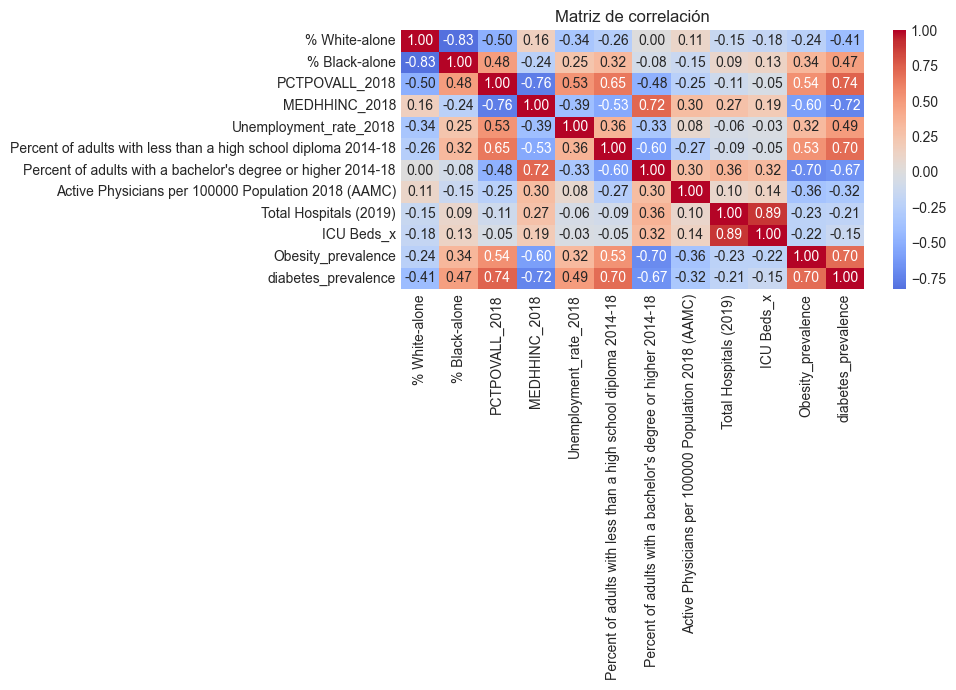

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_modelo.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

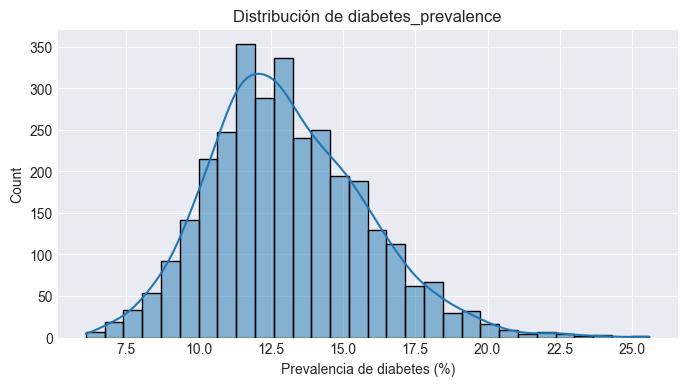

In [10]:
# Distribución del target
plt.figure(figsize=(8, 4))
sns.histplot(df_modelo[target], kde=True, bins=30)
plt.title('Distribución de diabetes_prevalence')
plt.xlabel('Prevalencia de diabetes (%)')
plt.show()

## 3. Preparación de datos y split

In [11]:
X = df_modelo[features]
y = df_modelo[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 2512 | Test: 628


## 4. Regresión Lineal base

In [12]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f'Regresión Lineal -> R2: {r2_lr:.4f} | RMSE: {rmse_lr:.4f}')

Regresión Lineal -> R2: 0.7598 | RMSE: 1.3898


## 5. Modelo Lasso y comparación de alpha

In [13]:
# Lasso con alpha por defecto
lasso = Lasso()
lasso.fit(X_train_sc, y_train)

y_pred_lasso = lasso.predict(X_test_sc)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f'Lasso (default) -> R2: {r2_lasso:.4f} | RMSE: {rmse_lasso:.4f}')
print(f'Regresión Lineal -> R2: {r2_lr:.4f} | RMSE: {rmse_lr:.4f}')

Lasso (default) -> R2: 0.5162 | RMSE: 1.9727
Regresión Lineal -> R2: 0.7598 | RMSE: 1.3898


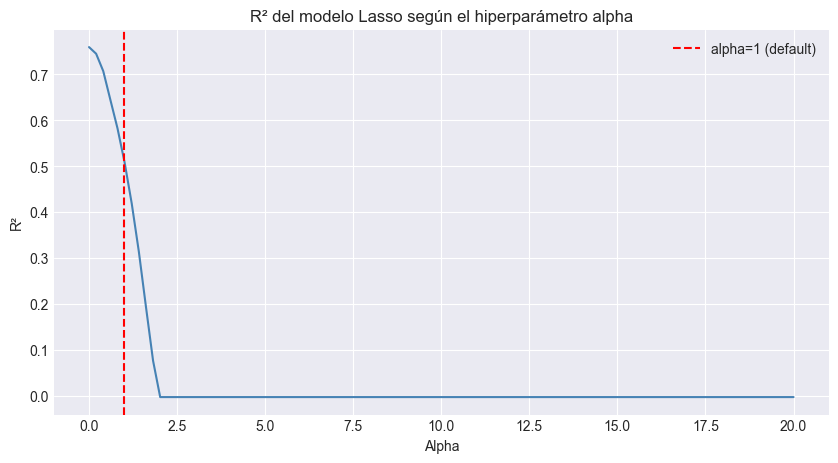

Mejor alpha: 0.01 con R2: 0.7597


In [14]:
# Cómo evoluciona R2 según alpha de Lasso (0 a 20)
alphas = np.linspace(0.01, 20, 100)
r2_vals = []

for a in alphas:
    m = Lasso(alpha=a)
    m.fit(X_train_sc, y_train)
    r2_vals.append(r2_score(y_test, m.predict(X_test_sc)))

plt.figure(figsize=(10, 5))
plt.plot(alphas, r2_vals, color='steelblue')
plt.axvline(x=1.0, color='red', linestyle='--', label='alpha=1 (default)')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('R² del modelo Lasso según el hiperparámetro alpha')
plt.legend()
plt.show()

best_alpha = alphas[np.argmax(r2_vals)]
print(f'Mejor alpha: {best_alpha:.2f} con R2: {max(r2_vals):.4f}')

## 6. Lasso optimizado con mejor alpha

In [15]:
lasso_opt = Lasso(alpha=best_alpha)
lasso_opt.fit(X_train_sc, y_train)

y_pred_opt = lasso_opt.predict(X_test_sc)
r2_opt = r2_score(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print('Comparativa final:')
print(f'  Regresión Lineal       -> R2: {r2_lr:.4f} | RMSE: {rmse_lr:.4f}')
print(f'  Lasso (alpha=default)  -> R2: {r2_lasso:.4f} | RMSE: {rmse_lasso:.4f}')
print(f'  Lasso (alpha={best_alpha:.2f})  -> R2: {r2_opt:.4f} | RMSE: {rmse_opt:.4f}')

Comparativa final:
  Regresión Lineal       -> R2: 0.7598 | RMSE: 1.3898
  Lasso (alpha=default)  -> R2: 0.5162 | RMSE: 1.9727
  Lasso (alpha=0.01)  -> R2: 0.7597 | RMSE: 1.3903


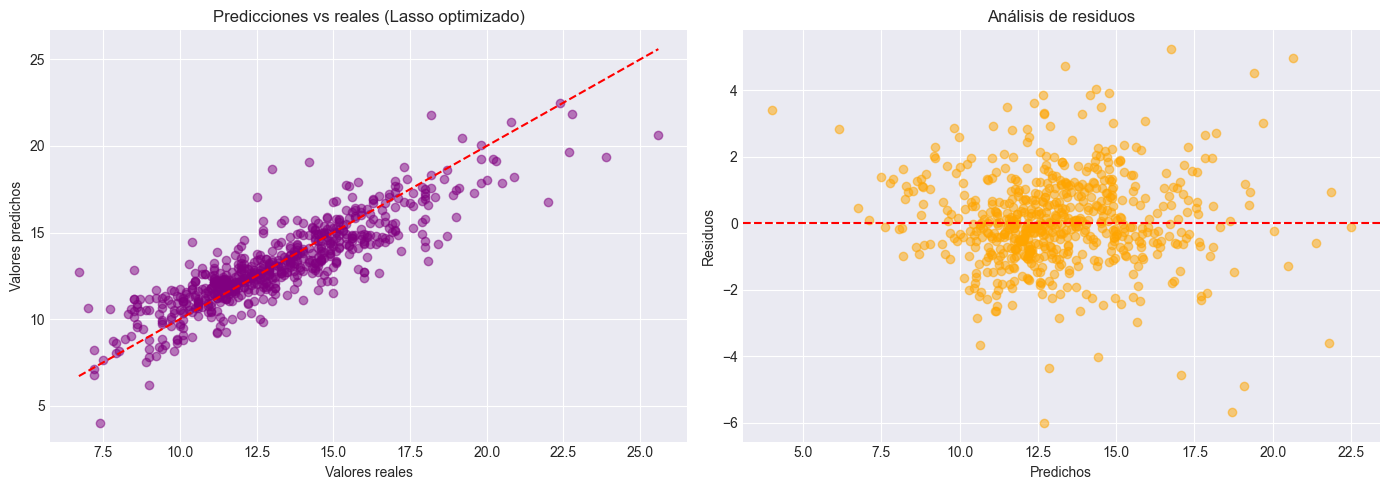

In [16]:
# Visualizar predicciones del mejor modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_opt, alpha=0.5, color='purple')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Valores predichos')
axes[0].set_title('Predicciones vs reales (Lasso optimizado)')

residuos = y_test - y_pred_opt
axes[1].scatter(y_pred_opt, residuos, alpha=0.5, color='orange')
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predichos')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Análisis de residuos')

plt.tight_layout()
plt.show()

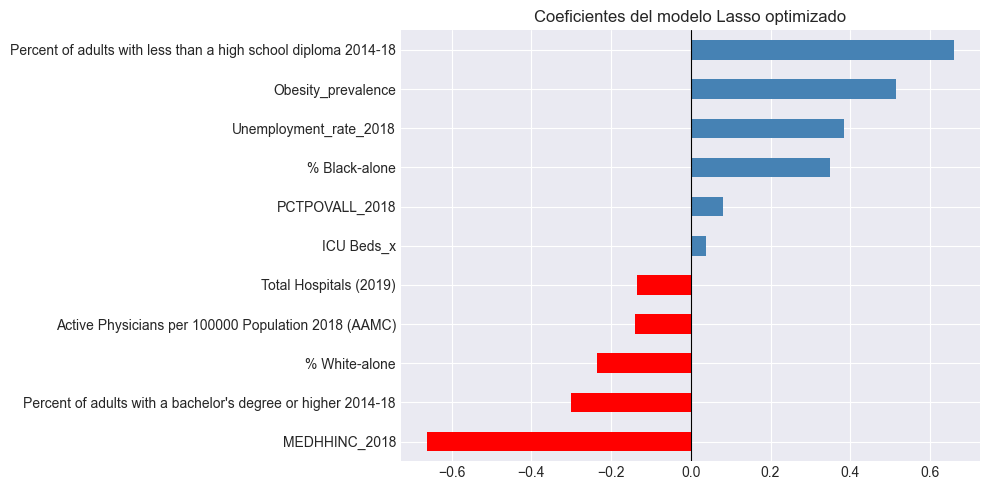

In [17]:
# Coeficientes del modelo Lasso (cuáles variables eliminó Lasso)
coefs = pd.Series(lasso_opt.coef_, index=features).sort_values()
plt.figure(figsize=(10, 5))
coefs.plot(kind='barh', color=['red' if c < 0 else 'steelblue' for c in coefs])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes del modelo Lasso optimizado')
plt.tight_layout()
plt.show()